# Data Cleaning and Preprocessing

In [3]:
import pandas as pd

# 1. Load Dataset
train_df = pd.read_csv('customer_churn_dataset-training-master.csv')
test_df = pd.read_csv('customer_churn_dataset-testing-master.csv')

print(f"Ukuran dataset Awal Train: {train_df.shape}")
print(f"Ukuran dataset Awal Test: {test_df.shape}")

# 2. Hapus baris yang memiliki nilai NaN terlebih dahulu
train_clean = train_df.dropna().copy()
test_clean = test_df.dropna().copy()

# 3. Hapus kolom CustomerID
train_clean = train_clean.drop(columns=['CustomerID'])
test_clean = test_clean.drop(columns=['CustomerID'])

# 4. Baru ubah tipe data Churn menjadi integer (setelah data bersih dari NaN)
train_clean['Churn'] = train_clean['Churn'].astype(int)
test_clean['Churn'] = test_clean['Churn'].astype(int)

print("\n--- Setelah Cleaning ---")
print(f"Ukuran Train: {train_clean.shape}")
print(f"Ukuran Test: {test_clean.shape}")
print("\nJumlah missing values di Train:", train_clean.isnull().sum().sum())
print("Jumlah missing values di Test:", test_clean.isnull().sum().sum())

Ukuran dataset Awal Train: (440833, 12)
Ukuran dataset Awal Test: (64374, 12)

--- Setelah Cleaning ---
Ukuran Train: (440832, 11)
Ukuran Test: (64374, 11)

Jumlah missing values di Train: 0
Jumlah missing values di Test: 0


# EDA and Visualization

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_27160\1279307940.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train_clean, x='Churn', palette='Set2')


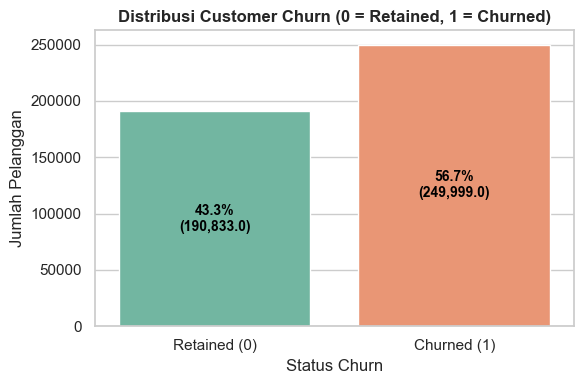

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_27160\1279307940.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x='Churn', y='Support Calls', ax=axes[0], palette='Set2')
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_27160\1279307940.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_27160\1279307940.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_clean, x='Churn', y='Payment Delay', ax=axes[1], palette='Set2')
C:\Users\Radja Triyasa\AppData\Local\Te

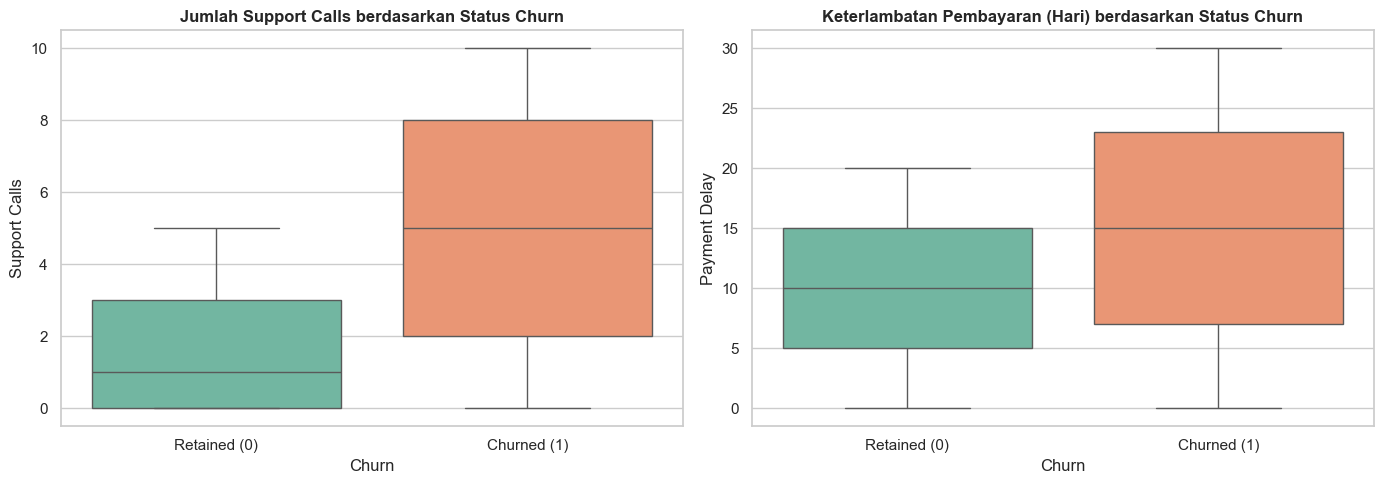

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style seaborn
sns.set_theme(style="whitegrid")

# 1. Grafik Distribusi Churn
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train_clean, x='Churn', palette='Set2')
plt.title('Distribusi Customer Churn (0 = Retained, 1 = Churned)', fontsize=12, fontweight='bold')
plt.xlabel('Status Churn')
plt.ylabel('Jumlah Pelanggan')
plt.xticks([0, 1], ['Retained (0)', 'Churned (1)'])

# Menambahkan label persentase
total = len(train_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%\n({p.get_height():,})'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_churn_distribution.png', dpi=300)
plt.show()

# 2. Perbandingan Panggilan Customer Support & Delay Pembayaran
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train_clean, x='Churn', y='Support Calls', ax=axes[0], palette='Set2')
axes[0].set_title('Jumlah Support Calls berdasarkan Status Churn', fontweight='bold')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])

sns.boxplot(data=train_clean, x='Churn', y='Payment Delay', ax=axes[1], palette='Set2')
axes[1].set_title('Keterlambatan Pembayaran (Hari) berdasarkan Status Churn', fontweight='bold')
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.savefig('eda_behavior_comparison.png', dpi=300)
plt.show()

# Feature Encoding & Scaling

In [5]:
# Gabungkan fitur kategorikal menggunakan One-Hot Encoding
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']

train_encoded = pd.get_dummies(train_clean, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_clean, columns=categorical_cols, drop_first=True)

# Pastikan kolom train dan test identik
X_train = train_encoded.drop(columns=['Churn'])
y_train = train_encoded['Churn']

X_test = test_encoded.drop(columns=['Churn'])
y_test = test_encoded['Churn']

# Menyesuaikan kolom jika ada ketidakcocokan urutan
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Fitur yang digunakan untuk pemodelan:")
print(X_train.columns.tolist())

Fitur yang digunakan untuk pemodelan:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction', 'Gender_Male', 'Subscription Type_Premium', 'Subscription Type_Standard', 'Contract Length_Monthly', 'Contract Length_Quarterly']


# Model Training & Evaluation

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# --- Model 1: Logistic Regression ---
print("--- Training Logistic Regression ---")
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_model.predict_proba(X_test)[:, 1]):.4f}")

# --- Model 2: Random Forest ---
print("\n--- Training Random Forest ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")

--- Training Logistic Regression ---


c:\Users\Radja Triyasa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.19      0.32     33881
           1       0.53      0.99      0.69     30493

    accuracy                           0.57     64374
   macro avg       0.74      0.59      0.50     64374
weighted avg       0.75      0.57      0.49     64374

ROC-AUC Score: 0.6863

--- Training Random Forest ---

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.06      0.11     33881
           1       0.49      1.00      0.66     30493

    accuracy                           0.50     64374
   macro avg       0.73      0.53      0.38     64374
weighted avg       0.75      0.50      0.37     64374

ROC-AUC Score: 0.5834


# Feature Importance & Business Insights

C:\Users\Radja Triyasa\AppData\Local\Temp\ipykernel_27160\2420324379.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


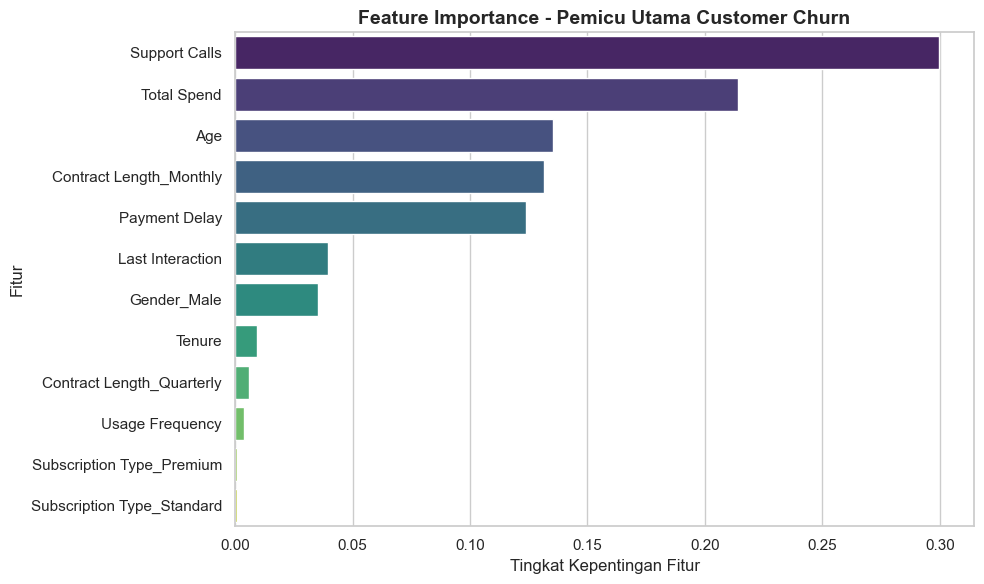


5 Fitur Paling Berpengaruh Terhadap Churn:
                    Feature  Importance
3             Support Calls    0.299559
5               Total Spend    0.214229
0                       Age    0.135202
10  Contract Length_Monthly    0.131531
4             Payment Delay    0.123752


In [7]:
# Ekstraksi Feature Importance dari Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - Pemicu Utama Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.ylabel('Fitur')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

print("\n5 Fitur Paling Berpengaruh Terhadap Churn:")
print(df_importance.head(5))